In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
s = pd.Series(data=[1, "2", [3], {"4"}],
              index=[3, "2", True, [0]])
s

3         1
2         2
True    [3]
[0]     {4}
dtype: object

In [4]:
s[True]

[3]

In [5]:
s[1:3]

2         2
True    [3]
dtype: object

In [6]:
df1 = pd.DataFrame([[1,2], ["1", "2"], [[],[]]])
df1

,0,1
0,1,2
1,1,2
2,[],[]


In [7]:
df2 = pd.DataFrame([[1,2], ["1", "2"], [3,4]], columns=['ноль','один'], index=['один','два','три'])
df2


,ноль,один
один,1,2
два,1,2
три,3,4


In [8]:
url = "data.csv"

In [9]:
df = pd.read_csv(url)
df.head()

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


Информация о столбцих и типах

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


Базовые описвтельные статистики

In [11]:
df.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


Проверка пропусков в df в каждом столбце

In [12]:
df.isnull().sum()

user_id      0
age          2
country      0
purchases    0
revenue      0
dtype: int64

Типы данных

In [13]:
df.dtypes

user_id        int64
age          float64
country       object
purchases      int64
revenue        int64
dtype: object

In [14]:
df.columns

Index(['user_id', 'age', 'country', 'purchases', 'revenue'], dtype='object')

Количество дублирующих строк

In [15]:
df.duplicated().sum()


np.int64(1)

Доля пропусков в каждом столбце

In [16]:
df.isna().mean()

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

Сами дублирующиеся строки

In [17]:
df[df.duplicated(keep=False)]

,user_id,age,country,purchases,revenue
9,10,24.0,RU,7,511
40,10,24.0,RU,7,511


In [18]:
df.dtypes

user_id        int64
age          float64
country       object
purchases      int64
revenue        int64
dtype: object

Провека качетсва

In [19]:
problems = {}

problems["null_user"] = df["user_id"].isna().sum()
problems["null_age"] = df["age"].isna().sum()
problems["null_country"] = df["country"].isna().sum()
problems["invalid_age"] = ((df["age"] < 0) | (df["age"] > 110)).sum()
problems["invalid_revenue"] = ((df["revenue"] < 0) | (df["revenue"] > 100000)).sum()
problems["invalid_wastes"] = ((df["revenue"] <= 0) & (df["purchases"] > 0)).sum()
problems["invalid_purchases"] = (df["purchases"] < 0).sum()

report = pd.Series(problems, name = "n_bad_rows")
print(report)

null_user            0
null_age             2
null_country         0
invalid_age          1
invalid_revenue      0
invalid_wastes       1
invalid_purchases    1
Name: n_bad_rows, dtype: int64


In [20]:
df

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296
5,6,120.0,FR,-1,785
6,7,46.0,RU,0,0
7,8,28.0,CN,2,456
8,9,39.0,US,4,980
9,10,24.0,RU,7,511


В данных присутствуют следующие проблемы качеста:
1 Найдено 2 случая с nan в значениии возраста
2 Найден 1 случай с нереалистичным возрастом
3 Найден 1 случай с несоответствием заработка и покупок
4 Найдено 1 некорректное значение покупок

Подсчет частот

In [21]:
df["country"].value_counts()

country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64

In [22]:
df["age"].value_counts()

age
24.0     5
52.0     2
31.0     2
39.0     2
28.0     2
35.0     2
47.0     2
32.0     2
20.0     1
25.0     1
46.0     1
120.0    1
22.0     1
57.0     1
36.0     1
5.0      1
33.0     1
42.0     1
21.0     1
54.0     1
43.0     1
55.0     1
26.0     1
23.0     1
45.0     1
51.0     1
18.0     1
34.0     1
Name: count, dtype: int64

Групировка с агрегатами

In [23]:
df.groupby("country")["age"].agg(['mean','sum','median'])

,mean,sum,median
country,,,
CN,24.000000,48.0,24.0
DE,34.600000,173.0,35.0
FR,46.250000,555.0,42.0
RU,30.076923,391.0,26.0
US,36.714286,257.0,39.0


In [24]:
df.groupby(["country","age"])["revenue"].mean()

country  age  
CN       20.0     1652.00
         28.0      456.00
DE       18.0     1104.00
         32.0     2475.00
         35.0      738.00
         36.0     2358.00
         52.0      702.00
FR       22.0      183.00
         25.0      749.00
         28.0        0.00
         32.0     1608.00
         33.0      546.00
         39.0     1162.00
         45.0      404.00
         47.0     1440.00
         52.0      399.00
         55.0      142.00
         57.0      693.00
         120.0     785.00
RU       5.0      1488.00
         21.0      650.00
         24.0      534.25
         26.0     1080.00
         31.0      548.00
         34.0     2086.00
         46.0        0.00
         47.0      432.00
         54.0     1302.00
US       23.0      445.00
         24.0        0.00
         35.0      330.00
         39.0      980.00
         42.0      904.00
         43.0      828.00
         51.0      342.00
Name: revenue, dtype: float64

Коридоры

In [25]:
bins = [0, 18, 30, 45, 60, 100]
labels = ['0–18', '19–30', '31–45', '46–60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

df['age_group'].value_counts()

age_group
31–45    14
19–30    13
46–60     9
0–18      2
60+       0
Name: count, dtype: int64

In [26]:
bins = [0, 100, 200, 300, 400, 500, 1000]
labels = ['0-100', '101-200', '201-300', '301-400', '401-500','501+']
df['revenue_group'] = pd.cut(df['revenue'], bins=bins, labels=labels)

df['revenue_group']

0        501+
1         NaN
2     301-400
3        501+
4         NaN
5        501+
6         NaN
7     401-500
8        501+
9        501+
10        NaN
11        NaN
12       501+
13        NaN
14       501+
15    101-200
16        NaN
17        NaN
18    401-500
19    401-500
20        NaN
21       501+
22       501+
23        NaN
24       501+
25    301-400
26        NaN
27       501+
28        NaN
29       501+
30    101-200
31        NaN
32    401-500
33        NaN
34    401-500
35    301-400
36        NaN
37       501+
38        NaN
39        NaN
40       501+
Name: revenue_group, dtype: category
Categories (6, object): ['0-100' < '101-200' < '201-300' < '301-400' < '401-500' < '501+']

В данном датафрейме преобладают следующие группы возрастов: "31-45"(14 чел) и "19-30"(13 чел)
Также в данном датафрейме пробладают люди с достатком 501+

Создание полотна и вывод типа

matplotlib.figure.Figure

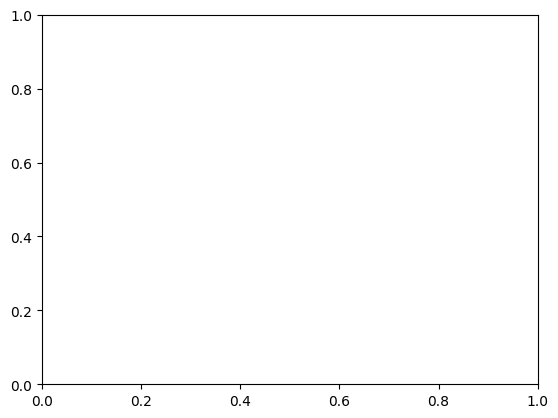

In [27]:
fig, _ = plt.subplots()
type(fig)

Stackplot

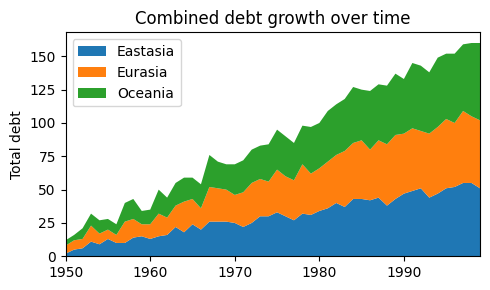

In [28]:
# задаем данные
rng = np.arange(50) #
rnd = np.random.randint(0, 10, size=(3, rng.size)) #
yrs = 1950 + rng #

fig, ax = plt.subplots(figsize=(5, 3)) # создаем полотно заданного размера
ax.stackplot(yrs, rng + rnd, labels=['Eastasia', 'Eurasia', 'Oceania']) # рисуем линии графиков, указав данные по оси х,оси у и названия графиков (метки)
ax.set_title('Combined debt growth over time') # название всего графика
ax.legend(loc='upper left') # отображаем подпись графиков, указывам его расположение
#plt.show() # выводим на экран все полотна
ax.set_ylabel('Total debt') # название оси ОУ
ax.set_xlim(xmin=yrs[0], xmax=yrs[-1]) # диапазон отображения для оси ОХ
fig.tight_layout() # более компактное раположение элементов графиков

plt.show() # выводим на экран все полотна

Зависимость между возрастом и доходом,распределение покупок и выручки

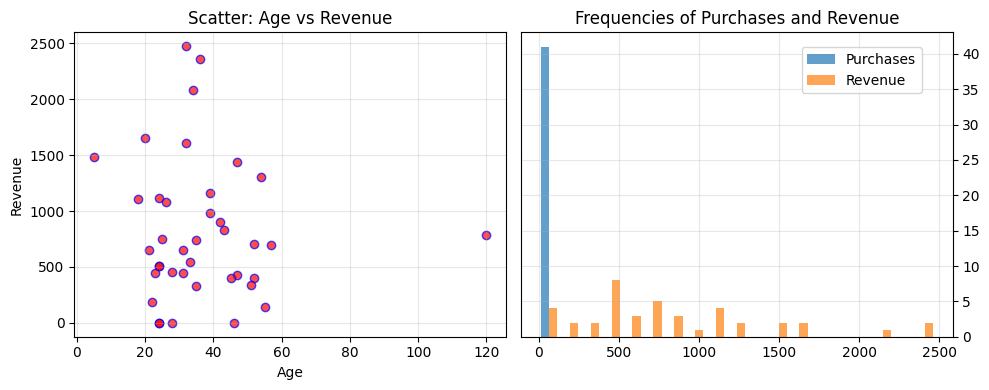

In [29]:
# Извлекаем числовые данные
age = df["age"].values
purchases = df["purchases"].values
revenue = df["revenue"].values

data = np.column_stack((purchases, revenue))

# Полотно из двух графиков
fig1, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 4)
)

# 1. Scatter plot: age vs revenue
ax1.scatter(
    x=age,
    y=revenue,
    marker='o',
    c='r',
    edgecolor='b',
    alpha=0.7
)
ax1.set_title('Scatter: Age vs Revenue')
ax1.set_xlabel('Age')
ax1.set_ylabel('Revenue')
ax1.grid(alpha=0.3)

# 2. Histogram: purchases и revenue
bins = np.linspace(data.min(), data.max(), 20)

ax2.hist(
    [purchases, revenue],
    bins=bins,
    label=('Purchases', 'Revenue'),
    alpha=0.7
)

ax2.legend(loc=(0.65, 0.8))
ax2.set_title('Frequencies of Purchases and Revenue')
ax2.yaxis.tick_right()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/scatter_hist_combined.png", dpi=200, bbox_inches='tight')
plt.show()

Гистограмма распределения дохода

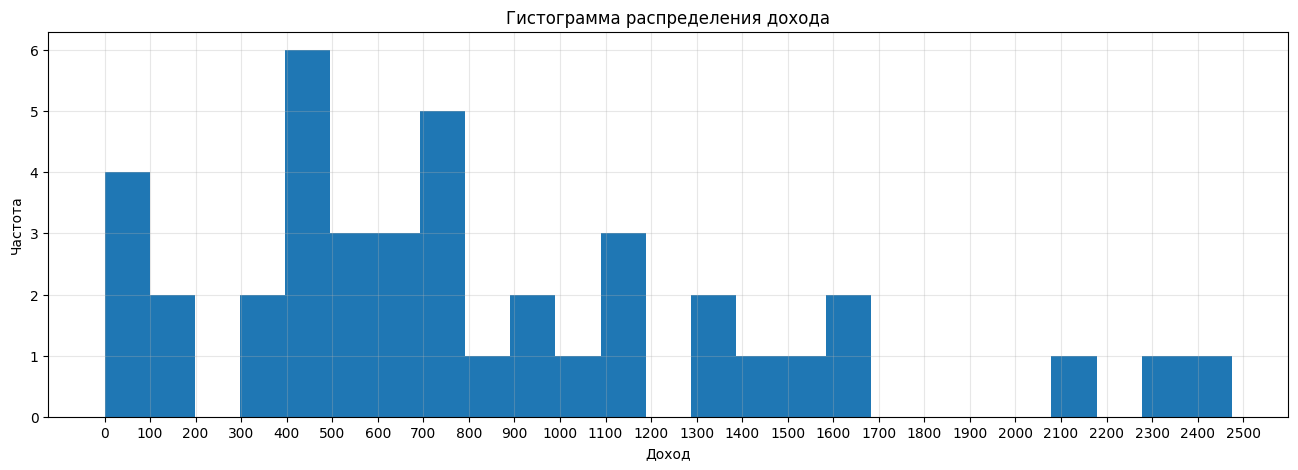

In [30]:
plt.figure(figsize=(16, 5))
df["revenue"].plot(kind="hist", bins=25)
plt.title("Гистограмма распределения дохода")
plt.xlabel("Доход")
plt.ylabel("Частота")
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, 2500 + 1, 100))

plt.savefig("figures/hist_revenue.png", dpi=200, bbox_inches='tight')
plt.show()

Гистограмма распределения возраста

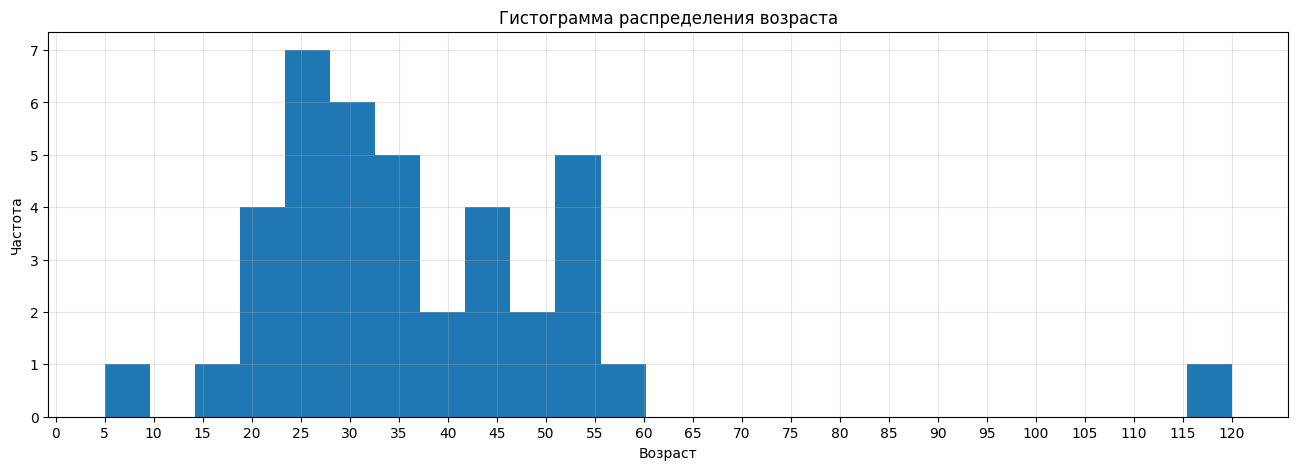

In [31]:
plt.figure(figsize=(16, 5))
df["age"].plot(kind="hist", bins=25)
plt.title("Гистограмма распределения возраста")
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, 120+1, 5))

plt.savefig("figures/hist_age.png", dpi=200, bbox_inches='tight')
plt.show()

Boxplot для визуализации доходов по стране

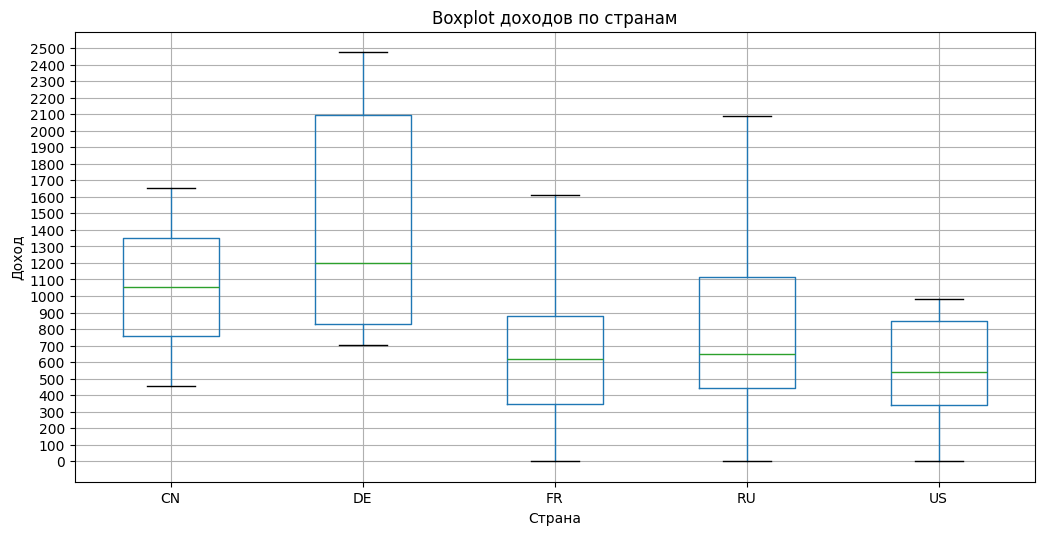

In [32]:
df.boxplot(column="revenue", by="country", figsize=(12, 6))

plt.title("Boxplot доходов по странам")
plt.suptitle("")
plt.xlabel("Страна")
plt.ylabel("Доход")
plt.yticks(np.arange(0, 2501, 100))

plt.savefig("figures/boxplot_revenue_by_country.png", dpi=200, bbox_inches='tight')
plt.show()


Диаграмма рассеивания дохода от возраста

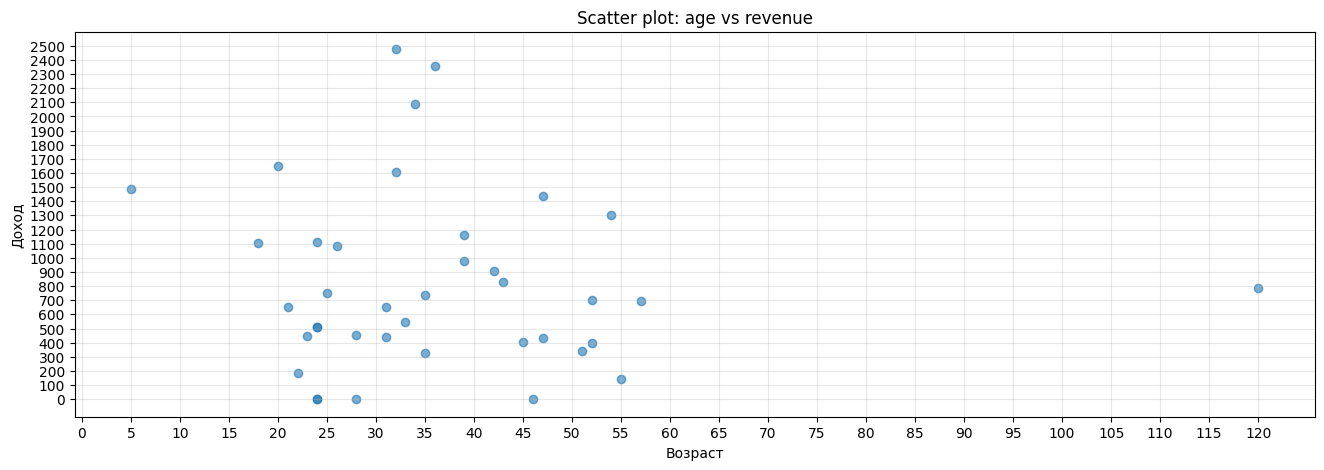

In [33]:
plt.figure(figsize=(16, 5))
plt.scatter(
    df["age"],
    df["revenue"],
    alpha=0.6
)
plt.title("Scatter plot: age vs revenue")
plt.xlabel("Возраст")
plt.ylabel("Доход")
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, 121, 5))
plt.yticks(np.arange(0, 2501, 100))

plt.savefig("figures/skater_plot_revenue_by_age.png", dpi=200, bbox_inches='tight')
plt.show()

In [34]:
import sys
sys.executable

'c:\\Users\\User\\Desktop\\al\\artificial-intelligence\\.venv\\Scripts\\python.exe'

Импортируем библиотеку Seaborn

In [35]:
import seaborn as sns

Гистограмма распределения дохода

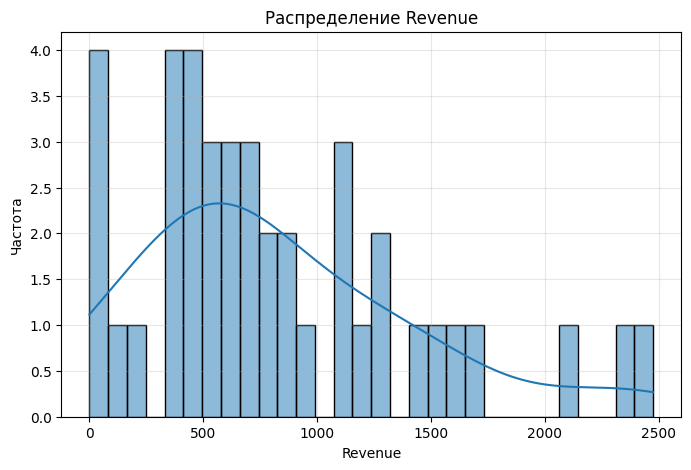

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="revenue",
    bins=30,
    kde=True                 # добавляет сглаженную плотность
)

plt.title("Распределение Revenue")
plt.xlabel("Revenue")
plt.ylabel("Частота")
plt.grid(alpha=0.3)

plt.savefig("figures/hist.png", dpi=200, bbox_inches='tight')
plt.show()

Распределение дохода от пользователей

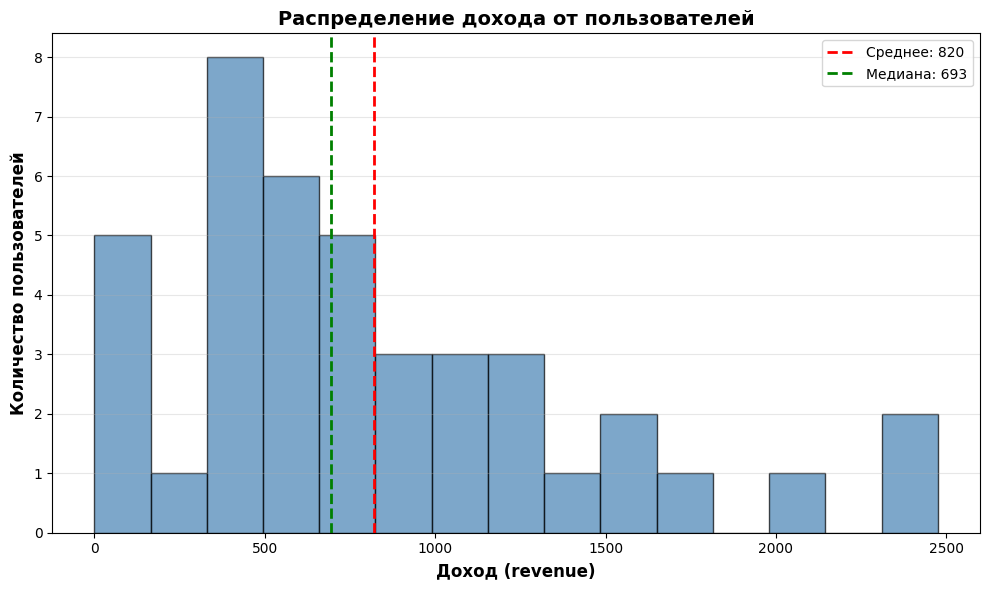

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(df['revenue'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Доход (revenue)', fontsize=12, fontweight='bold')
plt.ylabel('Количество пользователей', fontsize=12, fontweight='bold')
plt.title('Распределение дохода от пользователей', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
mean_revenue = df['revenue'].mean()
median_revenue = df['revenue'].median()
plt.axvline(mean_revenue, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_revenue:.0f}')
plt.axvline(median_revenue, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_revenue:.0f}')
plt.legend()

plt.tight_layout()
plt.savefig('figures/histogram_revenue2.png', dpi=300, bbox_inches='tight')
plt.show()